In [18]:
import kagglehub                      # Load data from kaggle
import pandas as pd                   # Dataframe manipulation library
import matplotlib.pyplot as plt       # Graphic/plot visualization library
import seaborn as sns                 # Graphic/plot visualization library
import statsmodels                    # Statistics Library
import patsy                          # For matrix design statistic
import os                             # Construct/system manipulations


# **Load Data**

In [2]:
path = kagglehub.dataset_download("vivek468/superstore-dataset-final")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'superstore-dataset-final' dataset.
Path to dataset files: /kaggle/input/superstore-dataset-final


In [3]:


# Construct the full path to the CSV file
csv_file_path = os.path.join(path, 'Sample - Superstore.csv')

# Load the CSV into a pandas DataFrame, specifying 'latin1' encoding
df = pd.read_csv(csv_file_path, encoding='latin1')

# Display the first 5 rows of the DataFrame
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [110]:
# Calculate total duplicated rows in the entire dataset
print("1. Duplicated Data Validation")
duplicate_count = df.duplicated().sum()
print(f"Total duplicated rows: {duplicate_count}")
if duplicate_count > 0:
    print("Warning: Found duplicated data! Consider using df.drop_duplicates()")
else:
    print("Clean: No duplicated rows found.")

# Ensure Ship Date is not earlier than Order Date
# Assumes both columns have been converted to datetime format previously
print("\n2. Date Anomaly Validation")
date_anomaly = df[df['Ship Date'] < df['Order Date']]
anomaly_count = len(date_anomaly)
#-------------------------------------------------------------------------------
print(f"Total rows with Ship Date earlier than Order Date: {anomaly_count}")
if anomaly_count > 0:
    print("Warning: Found date anomalies! Displaying the anomalous rows:")
    # Display only important columns for verification
    print(date_anomaly[['Order ID', 'Order Date', 'Ship Date', 'Customer ID']].head())
else:
    print("Clean: All shipping dates are logically after or equal to order dates.")
#-------------------------------------------------------------------------------

# Check for negative values in columns that should logically always be positive
print("\n3. Illegal Values Validation")
cols_to_check = ['Sales', 'Quantity']
has_negative = False

for col in cols_to_check:
    negative_rows = df[df[col] < 0]
    negative_count = len(negative_rows)
    print(f"Total negative values in '{col}': {negative_count}")

    if negative_count > 0:
        has_negative = True
        print(f"Warning: Found negative values in {col}! Examples:")
        print(negative_rows[['Order ID', 'Customer ID', col]].head())

if not has_negative:
    print("Clean: No illegal negative values found in Sales or Quantity columns.")

1. Duplicated Data Validation
Total duplicated rows: 0
Clean: No duplicated rows found.

2. Date Anomaly Validation
Total rows with Ship Date earlier than Order Date: 0
Clean: All shipping dates are logically after or equal to order dates.

3. Illegal Values Validation
Total negative values in 'Sales': 0
Total negative values in 'Quantity': 0
Clean: No illegal negative values found in Sales or Quantity columns.


# **Data Cleaning**

In [4]:
# Display rows have a missing values partially not all of it
df[df.isnull().any(axis=1)]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [6]:
# Replace data type from object/string to datetime
df[['Order Date', 'Ship Date']] = df[['Order Date', 'Ship Date']].apply(pd.to_datetime)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

# **Exploratory Data Analyst**

In [7]:
print("\nNumeric Column of Statistic\n")
print(df.describe().round(2))
print("\nCategorycal Column of Statistic")
print(df.describe(include=["object", "string"]))
print("\n")


Numeric Column of Statistic

        Row ID                     Order Date                      Ship Date  \
count  9994.00                           9994                           9994   
mean   4997.50  2016-04-30 00:07:12.259355648  2016-05-03 23:06:58.571142912   
min       1.00            2014-01-03 00:00:00            2014-01-07 00:00:00   
25%    2499.25            2015-05-23 00:00:00            2015-05-27 00:00:00   
50%    4997.50            2016-06-26 00:00:00            2016-06-29 00:00:00   
75%    7495.75            2017-05-14 00:00:00            2017-05-18 00:00:00   
max    9994.00            2017-12-30 00:00:00            2018-01-05 00:00:00   
std    2885.16                            NaN                            NaN   

       Postal Code     Sales  Quantity  Discount   Profit  
count      9994.00   9994.00   9994.00   9994.00  9994.00  
mean      55190.38    229.86      3.79      0.16    28.66  
min        1040.00      0.44      1.00      0.00 -6599.98  
25%      

## **Insight 1 | Discount Optimization**

In [8]:
# Identify rows with the most extreme losses
df_loss_major = df[df['Profit'] < 0].sort_values(by='Profit', ascending=True).head(10)

# View the correlation between Discount and Profit
correlation = df[['Discount', 'Profit', 'Sales']].corr()

# Group losses by Sub-Category and Discount
product_analysis = df[df['Profit'] < 0].groupby('Sub-Category')[['Profit', 'Discount','Quantity', 'Sales']].mean()

In [16]:
df['Total Cost'] = df['Sales'] - df['Profit']
df['Unit Cost'] = df['Total Cost'] / df['Quantity']
df['Org Unit Price'] = df['Sales'] / ((1 - df['Discount']) * df['Quantity'])

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Total Cost,Unit Cost,Org Unit Price,BE_Discount
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,220.0464,110.0232,130.98,0.16
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,512.3580,170.7860,243.98,0.30
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,7.7486,3.8743,7.31,0.47
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,1340.6085,268.1217,348.21,0.23
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,19.8516,9.9258,13.98,0.29


In [12]:
# Calculate the maximum safe discount limit (Original Margin / Potential Sales)
df['BE_Discount'] = 1 - (df['Total Cost'] / (df['Org Unit Price'] * df['Quantity']))

# Filter data where profit is negative to see if the discount exceeds the safe limit
df_loss = df[df['Profit'] < 0]
print(df_loss[['Discount', 'BE_Discount', 'Profit']])

      Discount  BE_Discount     Profit
3         0.45         0.23  -383.0310
14        0.80         0.44  -123.8580
15        0.80         0.50    -3.8160
23        0.30         0.29    -1.0196
27        0.50         0.23 -1665.0522
...        ...          ...        ...
9920      0.80         0.48   -35.8176
9921      0.70         0.46    -4.5936
9931      0.15         0.10   -40.1960
9937      0.20         0.18    -1.7772
9962      0.32         0.20   -67.6704

[1871 rows x 3 columns]


In [13]:
column_to_delete = 'Max_Safe_Discount'

In [14]:
# Grouping by discounts
diskon_perf = df.groupby('Discount').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Qty=('Quantity', 'sum'),
    Total_Profit=('Profit', 'sum'),
).reset_index()
print(diskon_perf)

    Discount   Total_Sales  Total_Qty  Total_Profit
0       0.00  1.087908e+06      18267   320987.6032
1       0.10  5.436935e+04        373     9029.1770
2       0.15  2.755852e+04        198     1418.9915
3       0.20  7.645944e+05      13660    90337.3060
4       0.30  1.032267e+05        849   -10369.2774
5       0.32  1.449346e+04        105    -2391.1377
6       0.40  1.164178e+05        786   -23057.0504
7       0.45  5.484974e+03         45    -2493.1111
8       0.50  5.891854e+04        241   -20506.4281
9       0.60  6.644700e+03        501    -5944.6552
10      0.70  4.062028e+04       1660   -40075.3569
11      0.80  1.696376e+04       1188   -30539.0392


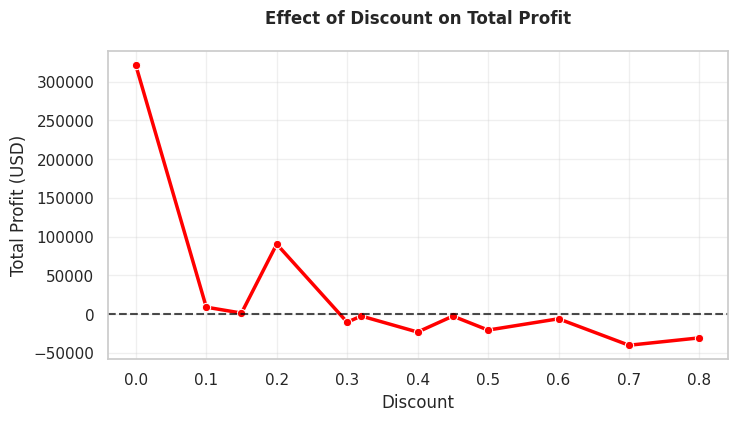

In [100]:
# Create a horizontal line at Profit = 0
sns.lineplot(data=diskon_perf, x='Discount', y='Total_Profit', marker='o', color='red', linewidth=2.5)

plt.axhline(0, color='black', linestyle='--', alpha=0.7)
plt.title('Effect of Discount on Total Profit', fontsize=12, fontweight='bold', pad=20)
plt.xlabel('Discount', fontsize=12)
plt.ylabel('Total Profit (USD)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

In [101]:
# Aggregate by Product Name, sorted by the most Quantity
df_discount_20 = df[df['Discount'] == 0.20]

top_products_20 = df_discount_20.groupby('Product Name').agg(
    Total_Qty=('Quantity', 'sum'),
    Total_Sales=('Sales', 'sum')
    ).sort_values(by='Total_Qty', ascending=False)

print("\nTop 10 Most Profitable Products at 20% Discount\n")
print(top_products_20.head(10))


Top 10 Most Profitable Products at 20% Discount

                                                    Total_Qty  Total_Sales
Product Name                                                              
Staples                                                   133      430.400
Easy-staple paper                                          49      689.552
Staple envelope                                            48      456.752
Newell 312                                                 44      205.568
GBC Premium Transparent Covers with Diagonal Li...         38      637.792
Staples in misc. colors                                    35      155.712
Storex Dura Pro Binders                                    35      166.320
Avery Non-Stick Binders                                    32      114.944
Staple remover                                             32      110.768
Wilson Jones Clip & Carry Folder Binder Tool fo...         31      143.840


In [102]:
# Aggregate by Product Name, sorted by the most Quantity
df_discount_20 = df[df['Discount'] == 0.20]

top_products_20 = df_discount_20.groupby('Sub-Category').agg(
    Total_Qty=('Quantity', 'sum'),
    Total_Sales=('Sales', 'sum')
    ).sort_values(by='Total_Qty', ascending=False)

# Display the results
print("\nTop 10 Most Profitable Sub-Category at 20% Discount\n")
print(top_products_20.head(10))


Top 10 Most Profitable Sub-Category at 20% Discount

              Total_Qty  Total_Sales
Sub-Category                        
Binders            2227    85442.640
Paper              1949    25321.336
Phones             1773   171789.992
Accessories        1141    49010.008
Storage            1114    65989.848
Art                1096     9104.152
Furnishings         899    23610.664
Chairs              889   120748.624
Labels              455     3246.752
Appliances          418    21759.288


In [98]:
# Identify states or regions contributing the largest total losses
state_profit_loss = df.groupby('State')['Profit'].sum().round(2).sort_values()
print("\nStates with the worst profit performance:")
print(state_profit_loss.head())


States with the worst profit performance:
State
Texas            -25729.36
Ohio             -16971.38
Pennsylvania     -15559.96
Illinois         -12607.89
North Carolina    -7490.91
Name: Profit, dtype: float64


### **Business Narrative & Actionable Insights**

#### **Context:**
Discounts are originally designed to boost sales volume and acquire new customers. However, an unmonitored discount strategy can severely erode profit margins. This analysis aims to evaluate the correlation between discount rates and profitability, identifying where financial leakages occur.

#### **Key Findings:**
1. **The 20% Threshold Trap:** There is a strong negative correlation between high discounts and profitability. Aggressive discounting creates a major deficit. Specifically, a flat discount of **20% or more** triggers a significant downward spiral, shifting transactions from profitable to heavily negative.
2. **Break-Even (BE) Discount Breach:** Many transactions have exceeded their maximum safe discount limit (*BE_Discount*), meaning the company is selling products below their total cost of goods sold (COGS) and operational costs.
3. **High-Loss Drivers:** The financial loss is heavily concentrated in specific sub-categories—such as **Binders and Appliances**—and is heavily prevalent in certain geographic areas, notably **Texas and Ohio**.

#### **Strategic Recommendations:**
* **Implement a Discount Cap:** Immediately restrict flat discounts to a maximum of **15%** for high-risk sub-categories (Binders & Appliances) across all standard retail transactions.
* **Dynamic Bundling Strategy:** Instead of offering direct price cuts on single items, transition to a volume-based bundling strategy (e.g., *"Buy 3 Get 10% Off"*). This ensures the increased volume compensates for the margin drop.
* **Regional Pricing & Policy Audit:** Conduct a targeted review of sales operations in Texas and Ohio. Investigate whether local sales teams are over-relying on discounts to meet sales targets at the expense of regional profitability.

## **Insight 2: Shipment Durations**

In [23]:
df['Shipping Duration'] = (df['Ship Date'] - df['Order Date']).dt.days
shipment = df.groupby('Ship Mode')['Shipping Duration'].mean().round(2).sort_values(ascending=True)
print(shipment)

Ship Mode
Same Day          0.04
First Class       2.18
Second Class      3.24
Standard Class    5.01
Name: Shipping Duration, dtype: float64


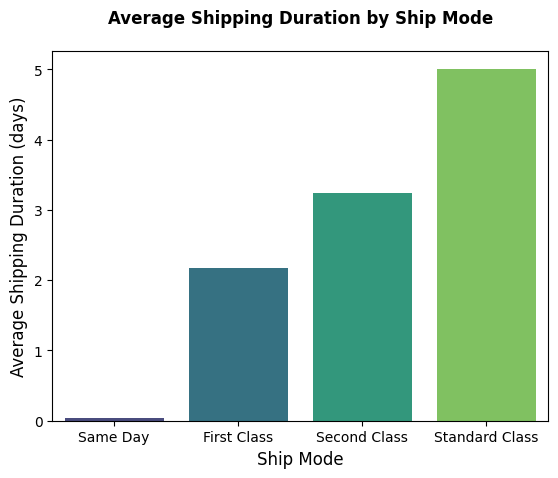

In [24]:
sns.barplot(x=shipment.index, hue=shipment.index , y=shipment.values, palette='viridis')
plt.title('Average Shipping Duration by Ship Mode', fontsize=12, fontweight='bold', pad=20)
plt.xlabel('Ship Mode', fontsize=12)
plt.ylabel('Average Shipping Duration (days)', fontsize=12)
plt.show()

### **Business Narrative & Actionable Insights**

#### **Context:**
Shipping efficiency is a cornerstone of customer satisfaction and operational logistics. This analysis evaluates the average fulfillment duration (the time elapsed between the `Order Date` and `Ship Date`) across different transportation modes to ensure the business meets its Service Level Agreements (SLAs).

#### **Key Findings:**
1. **SLA Alignment:** The operational data reflects a clear hierarchy in delivery speeds, where *Same Day* and *First Class* modes show the shortest durations, while *Standard Class* takes the longest.
2. **Bottleneck Assessment:** While the average duration aligns with general expectations, any significant variation or lag in the *Standard Class* or *Second Class* modes can lead to increased customer service inquiries and lower retention rates.

#### **Strategic Recommendations:**
* **Logistics Bottleneck Audit:** Identify the precise stage causing delays in the fulfillment pipeline (e.g., warehouse processing time vs. third-party carrier transit time).
* **Predictive Shipping Alerts:** Integrate a data-driven alert system that flags orders approaching their SLA threshold, allowing the operations team to expedite packing and dispatch.
* **Premium Upselling:** Utilize these baseline performance metrics in marketing campaigns to encourage customers to upgrade to *First Class* or *Same Day* shipping, thereby generating additional premium logistics revenue.

## **Insight 3: Customers Behavior**

In [97]:
# Calculate the number of unique sub-categories per Order ID
order_summary = df.groupby('Order ID')['Sub-Category'].nunique().reset_index()
order_summary.columns = ['Order ID', 'Unique_SubCategory_Count']

# See how many orders contain more than 1 sub-category
multi_subcategory_orders = order_summary[order_summary['Unique_SubCategory_Count'] > 1]
cross_buying_percentage = (len(multi_subcategory_orders) / len(order_summary)) * 100

print(f"Cross-Buying Percentage {cross_buying_percentage:.2f}%")

Cross-Buying Percentage 46.84%


In [33]:

# Find the anchor date (the last date in the entire dataset)
snapshot_date = df['Order Date'].max()

# Calculate RFM metrics
rfm = df.groupby('Customer ID').agg({

    # Recency: Days between snapshot_date and the customer's last purchase date
    'Order Date': lambda x: (snapshot_date - x.max()).days,
    # Frequency: Count of unique Order IDs for each customer
    'Order ID': 'nunique',
    # Monetary: Sum of Sales for each customer
    'Sales': 'sum'
}).sort_values(by='Sales',ascending=False)

# Rename columns for clarity
rfm.rename(columns={
    'Order Date': 'Recency',
    'Order ID': 'Frequency',
    'Sales': 'Monetary'
}, inplace=True)

print(rfm.head())

             Recency  Frequency   Monetary
Customer ID                               
SM-20320          79          5  25043.050
TC-20980         399          5  19052.218
RB-19360          96          6  15117.339
TA-21385          69          4  14595.620
AB-10105          41         10  14473.571


In [36]:
# Scoring Recency (Smallest value = Highest score)
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5, 4, 3, 2, 1])

# Scoring Frequency & Monetary (Highest value = Highest score)
# Note: For Frequency, many customers might have the exact same number of orders (e.g., just 1 order).
# Using .rank(method='first') prevents qcut from throwing a 'Bin edges must be unique' error.
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=5, labels=[1, 2, 3, 4, 5])

# Optional: Create a combined string score (e.g., "554") for easy referencing
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)


In [38]:
import re     # Regex lib for segmentation

# Define the segmentation map based on Recency and Freq scores
segt_map = {
    r'[4-5][4-5]': 'Champions',
    r'[2-5][3-5]': 'Loyal Customers',
    r'[3-5][1-2]': 'Potential Loyalists',
    r'[4-5]1': 'New Customers',
    r'33': 'Need Attention',
    r'[2-3][1-2]': 'About to Sleep',
    r'2[1-2]': 'Customers Entering Risk',
    r'[1-2][3-4]': 'At Risk',
    r'15': 'Can\'t Lose Them',
    r'1[1-2]': 'Hibernating'
}

# Create an 'R-F' string combo to map against the dictionary
rfm['Segment'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str)

# Replace the R-F scores with the human-readable segment names
rfm['Segment'] = rfm['Segment'].replace(segt_map, regex=True)

# Preview the final DataFrame
print(rfm[['Recency', 'Frequency', 'Monetary', 'Segment']].head(10))

             Recency  Frequency   Monetary              Segment
Customer ID                                                    
SM-20320          79          5  25043.050  Potential Loyalists
TC-20980         399          5  19052.218          Hibernating
RB-19360          96          6  15117.339      Loyal Customers
TA-21385          69          4  14595.620  Potential Loyalists
AB-10105          41         10  14473.571            Champions
KL-16645          47         12  14175.229            Champions
SC-20095         349          9  14142.334      Can't Lose Them
HL-15040          43          6  12873.298      Loyal Customers
SE-20110           9         11  12209.438            Champions
CC-12370          43          5  12129.072  Potential Loyalists


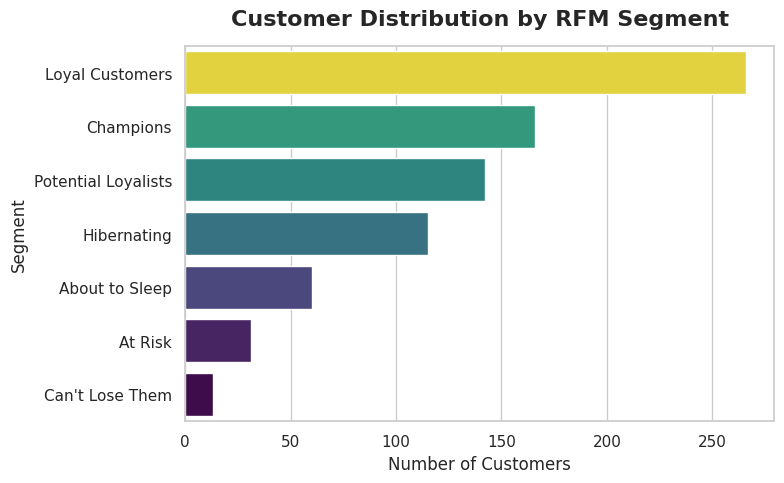

In [45]:
# Set figure size using rcParams to avoid plt.figure()
plt.rcParams['figure.figsize'] = (8, 5)
sns.set_theme(style="whitegrid")

# Get segment counts in descending order
segment_counts = rfm['Segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Count']

# Create barplot
ax = sns.barplot(x='Count', hue='Count' , legend=False, y='Segment', data=segment_counts, palette='viridis')
plt.title('Customer Distribution by RFM Segment', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Number of Customers', fontsize=12)
plt.ylabel('Segment', fontsize=12)
plt.tight_layout()

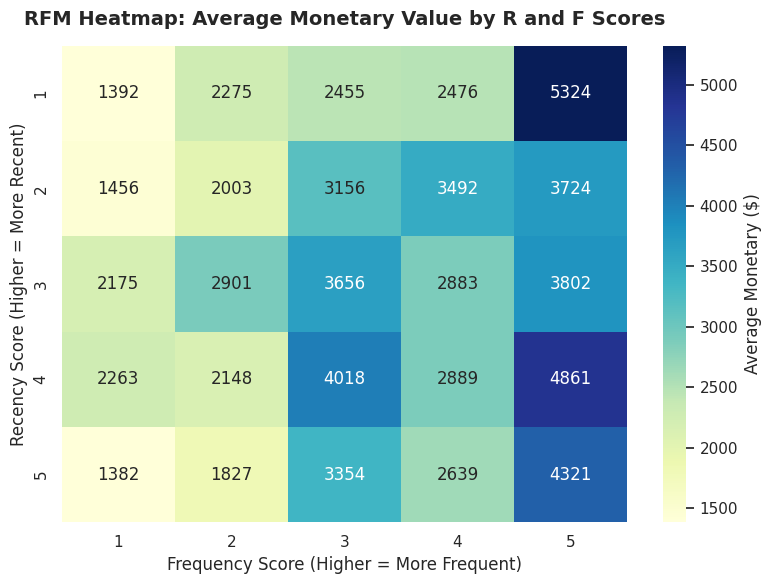

In [49]:
# Pivot table for R_Score vs F_Score (Average Monetary value)
heatmap_data = rfm.pivot_table(index='R_Score', columns='F_Score', values='Monetary', aggfunc='mean', observed=True)

# Sort index so R_Score 5 is at the top
heatmap_data = heatmap_data.sort_index(ascending=False)

plt.rcParams['figure.figsize'] = (8, 6)
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlGnBu", cbar_kws={'label': 'Average Monetary ($)'})
plt.title('RFM Heatmap: Average Monetary Value by R and F Scores', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Recency Score (Higher = More Recent)', fontsize=12)
plt.xlabel('Frequency Score (Higher = More Frequent)', fontsize=12)
plt.tight_layout()

### **Business Narrative & Actionable Insights**

#### **Context:**
Not all customers contribute equally to the business. To optimize marketing spend and maximize Customer Lifetime Value (CLV), we conducted an **RFM (Recency, Frequency, Monetary)** analysis to segment the customer base into distinct behavioral groups based on how recently they bought, how often they buy, and how much they spend.

#### **Key Findings:**
1. **Segment Distribution:** The segmentation reveals a diverse customer health profile. While we have a solid core of high-value customers (*Champions* and *Loyal Customers*), there is a visible portion of the database sitting in at-risk categories (*About to Sleep*, *At Risk*, or *Hibernating*).
2. **Revenue Disproportionality:** The heatmap highlights that a small percentage of top-tier segments (high R and F scores) contributes a massive share of the total *Monetary* value, emphasizing the risk if these customers churn.

#### **Strategic Recommendations:**
* **Champions & Loyal Customers (Nurture):** Launch an exclusive Loyalty Program or Early-Access Reward system. Do not waste marketing budget on discounting for this group; focus on relationship building and upselling premium products.
* **About to Sleep & Potential Loyalists (Re-engage):** Deploy personalized email automation workflows. Trigger a *"We Miss You"* campaign offering targeted incentives based on their previous purchase sub-categories to pull them back into the active cycle.
* **At Risk / Hibernating (Selective Win-Back):** Avoid expensive broad-spectrum campaigns. Filter this group by their past *Monetary* value; only target high-value historical spenders with aggressive win-back promotions, while letting low-value inactive accounts go to preserve marketing ROI.

## **Insight 4: Time-Series & Seasonality Growth**

In [56]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

df.head(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Quantity,Discount,Profit,Total Cost,Unit Cost,Org Unit Price,BE_Discount,Shipping Duration,Year,Month
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,2,0.0,41.9136,220.0464,110.0232,130.98,0.16,3,2016,11
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,3,0.0,219.5820,512.3580,170.7860,243.98,0.30,3,2016,11
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,2,0.0,6.8714,7.7486,3.8743,7.31,0.47,4,2016,6


In [114]:
# Calculate: Total Sales (sum), Average Sales (mean), and Number of Transactions (count)
monthly_tren = df.groupby(df['Order Date'].dt.to_period('M')).agg({
    'Sales': ['sum', 'mean'],
    'Order ID': 'nunique' # Count unique transactions per month
}).reset_index()

# 3. Clean up hierarchical column names (MultiIndex)
monthly_tren.columns = ['Month', 'Total_Sales', 'Avg_Sales', 'Total_Orders']

# 4. Convert 'Month' column back to string for easier visualization
monthly_tren['Month'] = monthly_tren['Month'].astype(str)

# Display the aggregated table
print(monthly_tren)

      Month  Total_Sales   Avg_Sales  Total_Orders
0   2014-01   14236.8950  180.213861            32
1   2014-02    4519.8920   98.258522            28
2   2014-03   55691.0090  354.719803            71
3   2014-04   28295.3450  209.595148            66
4   2014-05   23648.2870  193.838418            69
5   2014-06   34595.1276  256.260204            66
6   2014-07   33946.3930  237.387364            65
7   2014-08   27909.4685  182.414827            72
8   2014-09   81777.3508  305.139369           130
9   2014-10   31453.3930  197.820082            78
10  2014-11   78628.7167  247.260115           151
11  2014-12   69545.6205  250.164103           141
12  2015-01   18174.0756  313.346131            29
13  2015-02   11951.4110  186.740797            36
14  2015-03   38726.2520  280.625014            79
15  2015-04   34195.2085  213.720053            72
16  2015-05   30131.6865  206.381414            74
17  2015-06   24797.2920  179.690522            68
18  2015-07   28765.3250  205.4

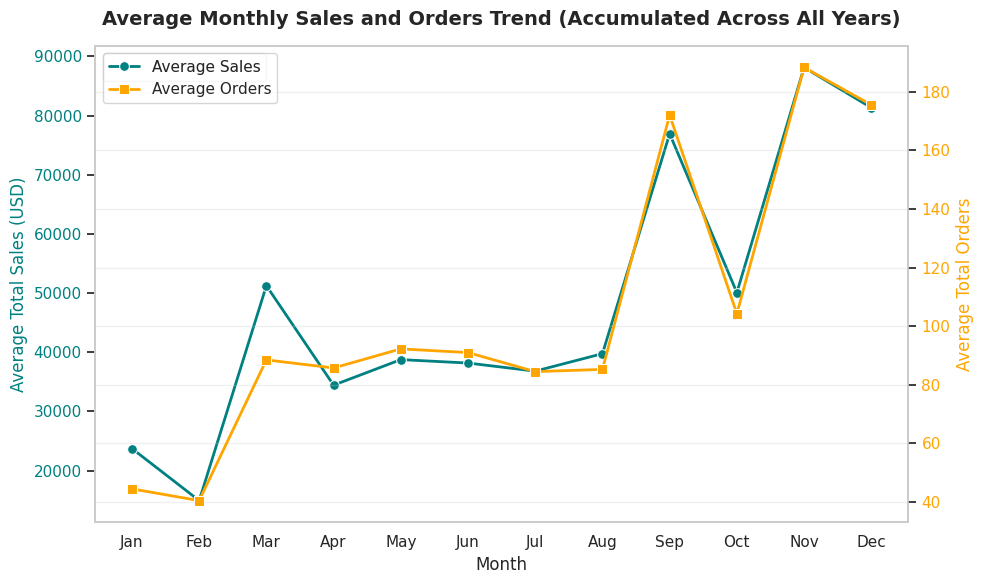

In [129]:
months_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Ensure monthly_tren has 'Month_Name' as a categorical type for correct ordering
monthly_tren['Month_Name'] = pd.Categorical(monthly_tren['Month_Name'], categories=months_order, ordered=True)

# Calculate average monthly sales and orders
avg_monthly_sales = monthly_tren.groupby('Month_Name', observed=True)['Total_Sales'].mean().reset_index()
avg_monthly_orders = monthly_tren.groupby('Month_Name', observed=True)['Total_Orders'].mean().reset_index()

# Line chart setup with two y-axes
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style="whitegrid")

fig, ax1 = plt.subplots() # Create a figure and a set of subplots

# Plot Average Monthly Sales on ax1
color_sales = 'Teal'
ax1.set_xlabel('Month', fontsize=12)
ax1.set_ylabel('Average Total Sales (USD)', color=color_sales, fontsize=12)
sns.lineplot(x='Month_Name', y='Total_Sales', data=avg_monthly_sales, marker='o', color=color_sales, linewidth=2, markersize=7, ax=ax1, label='Average Sales')
ax1.tick_params(axis='y', labelcolor=color_sales)
ax1.grid(False) # Disable grid for ax1, let ax2 handle it

# Instantiate a second axes that shares the same x-axis
ax2 = ax1.twinx()

# Plot Average Monthly Orders on ax2
color_orders = 'Orange' # Choose a different color for orders
ax2.set_ylabel('Average Total Orders', color=color_orders, fontsize=12)
sns.lineplot(x='Month_Name', y='Total_Orders', data=avg_monthly_orders, marker='s', color=color_orders, linewidth=2, markersize=7, ax=ax2, label='Average Orders')
ax2.tick_params(axis='y', labelcolor=color_orders)
ax2.grid(True, alpha=0.3) # Enable grid for ax2

# Add title
plt.title('Average Monthly Sales and Orders Trend (Accumulated Across All Years)', fontsize=14, fontweight='bold', pad=15)

# Add legends for both lines
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')
plt.tight_layout()
plt.show()

### **Business Narrative & Actionable Insights**

#### **Context:**
Retail businesses are highly susceptible to macroeconomic cycles and seasonal demand shifts. By analyzing historical sales and transaction volume trends month-over-month and accumulating them across multiple years, the business can accurately forecast peak seasons and optimize resource allocation.

#### **Key Findings:**
1. **Q4 Cyclical Surge:** The time-series visualization exhibits a clear, predictable seasonal pattern. Sales and transaction volumes experience a massive spike during the fourth quarter (**Q4 - especially September, November, and December**). This aligns with corporate budgeting cycles and year-end holiday shopping.
2. **Q1 Post-Holiday Slump:** Conversely, the first quarter (**Q1 - January and February**) routinely suffers from a severe revenue contraction as consumer spending cools down post-holidays.

#### **Strategic Recommendations:**
* **Supply Chain & Inventory Pre-Ordering:** Scale up inventory levels for top-selling product categories 2–3 months prior to the Q4 surge (starting in June/July) to prevent stockouts and capitalize entirely on peak demand.
* **Workforce & Logistics Scaling:** Adjust warehouse staffing and partner carrier capacities to handle the high transaction volume expected between September and December, minimizing fulfillment delays.
* **Q1 Defensive Campaigns:** To combat the low-revenue slump in January and February, launch aggressive clearance sales, new-year corporate contract renewals, or introduction of new product lines to stimulate artificial demand during the off-peak season.

In [123]:
df.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Discount,Profit,Total Cost,Unit Cost,Org Unit Price,BE_Discount,Shipping Duration,Year,Month,Month_Name
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,0.00,41.9136,220.0464,110.0232,130.98,0.16,3,2016,11,November
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,0.00,219.5820,512.3580,170.7860,243.98,0.30,3,2016,11,November
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,0.00,6.8714,7.7486,3.8743,7.31,0.47,4,2016,6,June
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,0.45,-383.0310,1340.6085,268.1217,348.21,0.23,7,2015,10,October
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,0.20,2.5164,19.8516,9.9258,13.98,0.29,7,2015,10,October
